# Strecthing based noise monitoring in the context of High noise variations

We implement a solution to permform noise monitoring in a context where the source environment changes brutally (e.g. day/night, high tide/low tide, traffic open/closed).

We impose a continuous stretching of the noise correlation function and attempt to recover it despite these strong noise changes.

In [1]:
# modules
import numpy as np
import matplotlib.pyplot as plt

from coodddaaaa.butter import BandpassFilter
from coodddaaaa.utils import TukeyWindow
from coodddaaaa.stretching import Stretcher

## Parameters

In [2]:
# parameters
t0 = -512 * 0.005  # start time in sec
nt = 1024          # number of time samples in the correlation function
dt = 0.005         # sampling of the correlation function
ntraces = 250      # number of correlation function (i.e. duration of monitoring)
freqmin = 5.0      # lower frequency range Hz
freqmax = 20.0     # upper frequency range Hz
tap0 = 0.2         # 4 points tapering window
tap1 = 0.6         # 4 points tapering window
tap2 = 1.0         # 4 points tapering window
tap3 = 2.0         # 4 points tapering window

In [3]:
t = t0 + np.arange(nt) * dt  # lag time array
T = np.arange(ntraces)       # calendar time array

# band pass filter
bpf = BandpassFilter(
    freqmin=freqmin,
    freqmax=freqmax,
    sampling_rate=1./dt,
    order=4)

# noise correlation tapering function
twin = TukeyWindow(tap0, tap1, tap2, tap3)
tap = twin(t) + twin(-t)

#### Generate the centroids correlation functions for each source environment

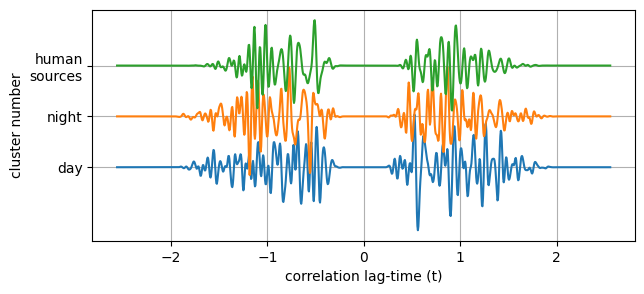

In [4]:
# Centroids
u0 = np.random.randn(nt)   # e.g. day
u1 = np.random.randn(nt)   # e.g. night
u2 = np.random.randn(nt)   # e.g. human sources 

u0 = tap * bpf.timecall(u0)
u1 = tap * bpf.timecall(u1)
u2 = tap * bpf.timecall(u1)
plt.figure(figsize=(7, 3))
plt.plot(t, u0, t, u1+1, t, u2+2);
plt.gca().set_xlabel('correlation lag-time (t)');
plt.gca().set_ylabel('cluster number');
plt.gca().set_yticks([0, 1, 2])
plt.gca().set_yticklabels(["day", "night", "human\nsources"])

plt.gca().grid(True);

#### Generate the expected strething history $ \varepsilon ^{true} (T) $, continuous in time.

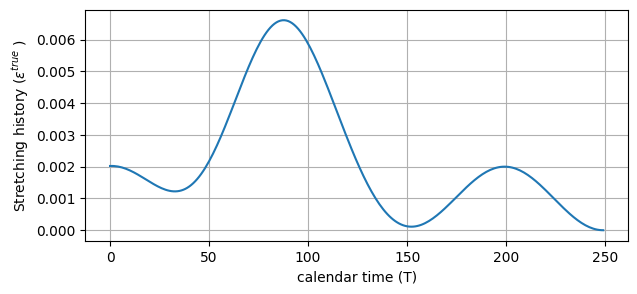

In [5]:
eps_true = 0.001 * np.cos(5. * np.pi * np.linspace(0, 1, ntraces)) +0.001
#eps_true += np.linspace(-0.004, 0.004, len(eps_true))
eps_true += 0.005 * np.exp(-0.5 * ((np.linspace(0, 1, ntraces) - 0.33) / 0.1)**2.)
                   
plt.figure(figsize=(7, 3))
plt.plot(T, eps_true);
plt.gca().set_xlabel('calendar time (T)')
plt.gca().set_ylabel('Stretching history ($ \epsilon ^{true} $ )')
plt.gca().grid(True);

#### Generate the source variation history.

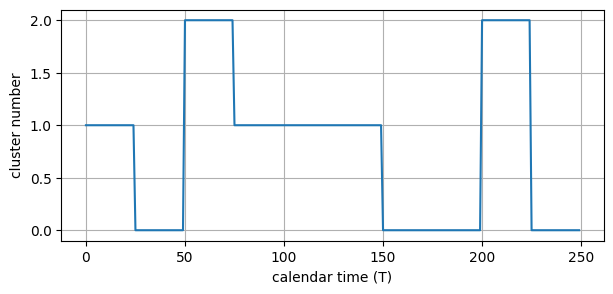

In [6]:
cluster_affiliations_true = np.round(2*np.random.rand(ntraces // 25)).repeat(25).astype(int)
assert len(cluster_affiliations_true) == ntraces

plt.figure(figsize=(7, 3))
plt.plot(cluster_affiliations_true);
plt.gca().set_xlabel('calendar time (T)')
plt.gca().set_ylabel('cluster number');
plt.gca().grid(True);

#### Generate the noise correlation functions, add random noise.

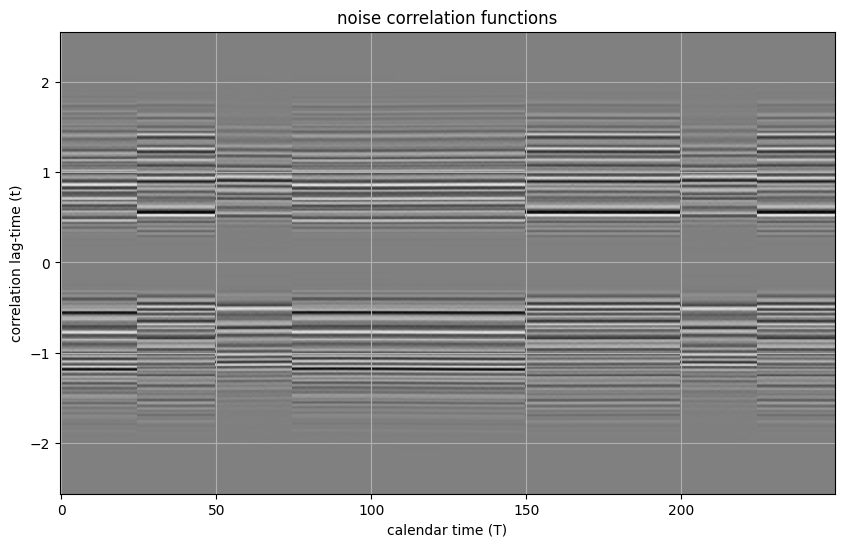

In [7]:
st_true = Stretcher(t0=t0, nt=nt, dt=dt, eps=eps_true)
u0_stretched = st_true.stretch(u0)
u1_stretched = st_true.stretch(u1)
u2_stretched = st_true.stretch(u2)

data = np.asarray(
    [[u0_stretched[n, :], 
      u1_stretched[n, :],
      u2_stretched[n, :],
      ][i] 
      for n, i in enumerate(cluster_affiliations_true)])

for i in range(data.shape[0]):
    data[i, :] += 0.05 * bpf.timecall(np.random.randn(nt)) * tap

plt.figure(figsize=(10, 6))
plt.pcolormesh(
    T, t, data.T,
    vmin=-np.abs(data).max(), vmax=np.abs(data).max(),
    cmap=plt.get_cmap('gray'),
    shading="auto");
plt.gca().set_title('noise correlation functions')
plt.gca().set_xlabel('calendar time (T)')
plt.gca().set_ylabel('correlation lag-time (t)');
plt.gca().grid(True);

#### Perform stretching measurements

In [8]:
# Define the epsilon grid to use for the stretching correlation computation
pw = 3
eps_search = np.linspace(-(0.3) ** (1. / pw), (0.3) ** (1. / pw), 200) ** pw
st_search = Stretcher(t0=t0, nt=nt, dt=dt, eps=eps_search)

In [9]:
# compute the stretching correlation function X for each pair of correlation functions 
# (only the upper triangle of the cross matrix)
c_triu, e_triu = st_search.corr_all_with_all(data)

# convert triangular matrix to square one
c = st_search.triu2dense(c_triu, True, 1.)
e = st_search.triu2dense(e_triu, False, 0.)

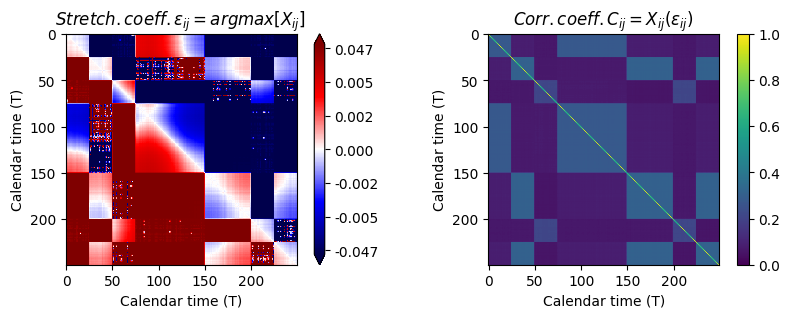

In [10]:
plt.figure(figsize=(10, 3))

plt.subplot(121,
            title=r"$ Stretch. coeff. \varepsilon_{ij}=argmax[X_{ij} ] $ ",
            sharex=plt.gca(), sharey=plt.gca())

# tick transformation for better visualisation of small/high values
f = lambda e: np.arctan(e * 300.0)  # transform stretching into values to be plotted
finv = lambda fe: np.tan(fe) / 300.  # inverse transform

plt.colorbar(
    plt.imshow(
        f(e),
        vmin=f(e).min(), vmax=f(e).max(),
        cmap=plt.get_cmap('seismic')),
    format=lambda tick, _: f"{finv(tick):.3f}",
    extend="both")
plt.gca().set_xlabel("Calendar time (T)")
plt.gca().set_ylabel("Calendar time (T)")

plt.subplot(122, 
            title=r"$ Corr. coeff. C_{ij}=X_{ij}(\varepsilon_{ij}) $ ")
plt.colorbar(
    plt.imshow(c, 
               vmin=0., vmax=1., 
               cmap=plt.get_cmap('viridis')));
plt.gca().set_xlabel("Calendar time (T)")
plt.gca().set_ylabel("Calendar time (T)");

#### title

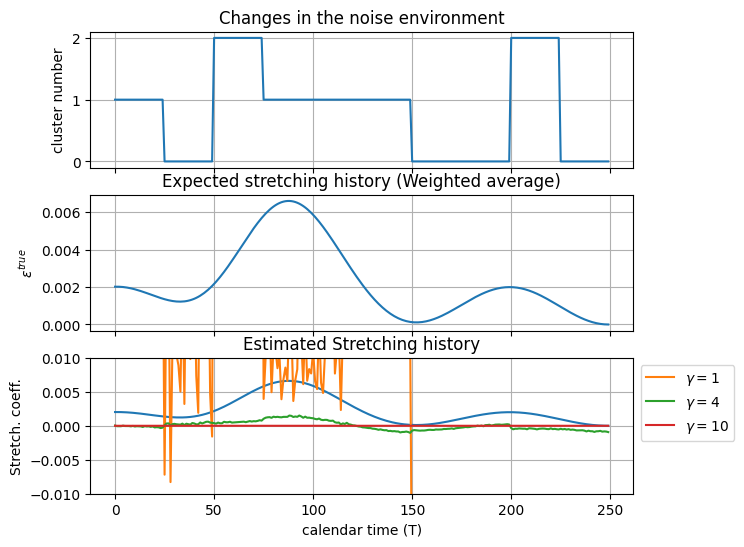

In [11]:
plt.figure(figsize=(7, 6))

plt.subplot(311)
plt.plot(T, cluster_affiliations_true)
plt.gca().set_title('Changes in the noise environment');
plt.gca().set_ylabel('cluster number');
plt.gca().set_xticklabels([])
plt.gca().grid(True)

plt.subplot(312)
plt.plot(T, eps_true)
plt.gca().set_title('Expected stretching history (Weighted average)')
plt.gca().set_ylabel('$ \epsilon ^{true} $')
plt.gca().set_xticklabels([])
plt.gca().grid(True)

plt.subplot(313)
plt.plot(T, eps_true)
for gamma in [1, 4, 10]:
    eps_av = np.mean(c ** gamma * e, axis=0) / np.mean(c ** gamma, axis=0)
    plt.plot(T, eps_av, label=r"$\gamma= $" + str(gamma))
plt.gca().legend(loc=1, bbox_to_anchor=(1.2, 1.))
plt.gca().grid(True)
plt.gca().set_ylim(-0.01, 0.01)
plt.gca().set_title('Estimated Stretching history')
plt.gca().set_xlabel('calendar time (T)');
plt.gca().set_ylabel('Stretch. coeff.');



The obtained stretching history is dominated by the changes in the noise sources.  
The reason is that we incorporate stretching measurement between pairs of correlation functions obtained in completely different noise environments.  
On top of this we recover the expected history.

## Clustering approach to separate the noise environments

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform

def waveform_distances(correlation_matrix: np.ndarray, power: float = 1.0) -> np.ndarray:
    """
    get distance from corr coeff, move to condensed distance matrix
    :param correlation_matrix: correlation coefficient matrix from waveform_corr_coeff
    :param power:
    :return:
    """
    condensed_distances = squareform((1. - correlation_matrix) ** power)
    return condensed_distances

def waveform_clustering(
    data_traces: np.ndarray,
    condensed_distances: np.ndarray,
    n_clusters: int = 10,
    sort_by: str="distance",
    master: str="average"):

    # 1 row = 1 trace,
    n_traces, n_dim = data_traces.shape
    assert len(condensed_distances) == (n_traces * (n_traces - 1)) // 2

    links = linkage(condensed_distances, method="ward")

    cluster_affiliations = fcluster(links, t=n_clusters, criterion='maxclust') - 1

    _, cluster_counts = np.unique(cluster_affiliations, return_counts=True)

    cluster_masters = np.zeros((n_clusters, n_dim), data_traces.dtype)

    for n_cluster in range(n_clusters):
        cluster_mask = cluster_affiliations == n_cluster
        if master == "average":
            cluster_masters[n_cluster, :] = data_traces[cluster_mask, :].mean(axis=0)

        elif master == "median":
            cluster_masters[n_cluster, :] = np.median(data_traces[cluster_mask, :], axis=0)

        else:
            raise ValueError(master)

    # sort_by seems to have no effect
    clustering_index = dendrogram(links, no_plot=True, count_sort=False, distance_sort=True)['leaves']
#   # clustering_index = dendrogram(links, no_plot=True, count_sort=True, distance_sort=False)['leaves']
    if False:
        # QC
        # from scipy.cluster.hierarchy import optimal_leaf_ordering
        # links = optimal_leaf_ordering(links, condensed_distances) # takes a while and has no effect
        show_clustering(links, condensed_distances)

    return cluster_masters, cluster_affiliations, cluster_counts, clustering_index

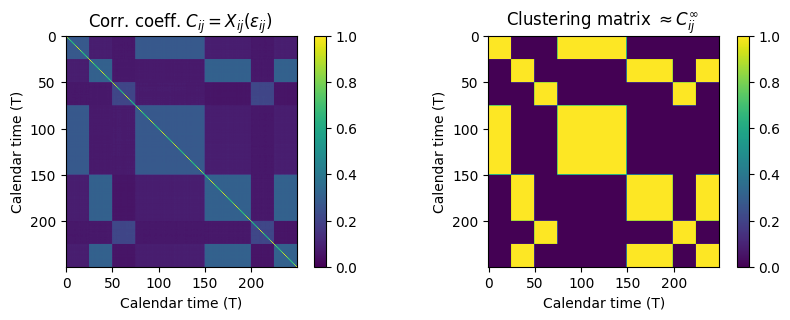

In [13]:
pw = 4
cluster_centroids, cluster_affiliations, \
    cluster_counts, sort_index = \
        waveform_clustering(
            data_traces=data,
            condensed_distances=waveform_distances(c ** pw),
            n_clusters=3,
            sort_by="distance",
            master="median")
c1 = (cluster_affiliations[:,np.newaxis] == cluster_affiliations).astype(float)

plt.figure(figsize=(10, 3))
plt.subplot(121, title=r"Corr. coeff. $ C_{ij}=X_{ij}(\varepsilon_{ij}) $ ")
plt.colorbar(
    plt.imshow(c, vmin=0., vmax=1., cmap=plt.get_cmap('viridis')))
plt.gca().set_xlabel("Calendar time (T)")
plt.gca().set_ylabel("Calendar time (T)");

plt.subplot(122, title=r"Clustering matrix $ \approx C_{ij}^{\infty}$ ")
plt.colorbar(
    plt.imshow(c1, vmin=0., vmax=1., cmap=plt.get_cmap('viridis')));
plt.gca().set_xlabel("Calendar time (T)")
plt.gca().set_ylabel("Calendar time (T)");

#### Using the clustering matrix to weight the stretching measurements

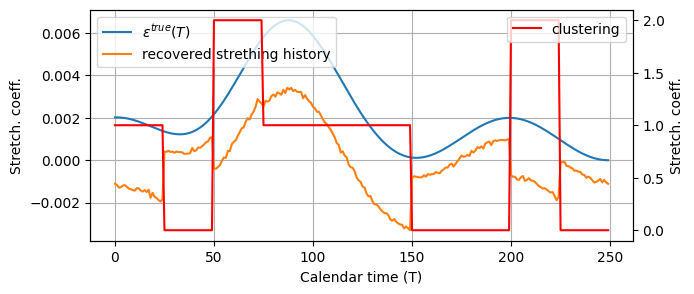

In [14]:
eps_av1 = np.mean(c1 * e, axis=0) / np.mean(c1, axis=0)
plt.figure(figsize=(7, 3))
plt.plot(T, eps_true, label=r"$ \varepsilon^{true}(T) $")
plt.plot(T, eps_av1, label="recovered strething history");

plt.gca().grid(True);
plt.gca().set_xlabel("Calendar time (T)")
plt.gca().set_ylabel("Stretch. coeff.")
plt.gca().legend(loc=2);

ax = plt.gca().twinx()
ax.plot(T, cluster_affiliations,'r', label="clustering");
ax.set_ylabel("Stretch. coeff.")
ax.legend(loc=1);

#### Inversion to adjust the constant terms of each cluster

Optimization terminated successfully.
         Current function value: 0.000007
         Iterations: 2
         Function evaluations: 5
         Gradient evaluations: 5


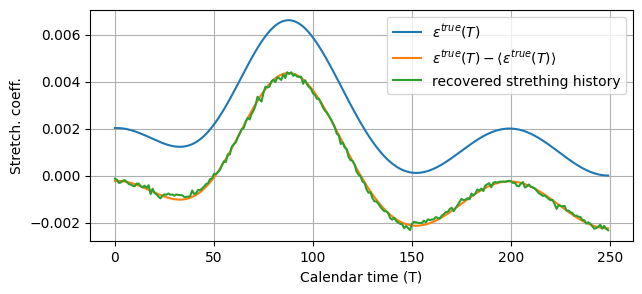

In [15]:
from scipy import optimize

mask0 = (cluster_affiliations==0)#.astype(float)
mask1 = (cluster_affiliations==1)#.astype(float)
mask2 = (cluster_affiliations==2)#.astype(float)

mask0f, mask1f, mask2f = [mask.astype(float) for mask in [mask0, mask1, mask2]]

def eps_av_corr(i, j, k):
    _eps_av_corr = eps_av1 + i * mask0f + j * mask1f + k * mask2f
    _eps_av_corr -= _eps_av_corr.mean()
    return _eps_av_corr

def cost_function(model):
    i, j, k = model
    e = eps_av_corr(i, j, k)
    g = e[2:] - 2 * e[1:-1] + e[:-2]
    return (g ** 2.).sum()

def grad_cost_function(model):
    # TODO implement analytical gradient of cost_function
    i, j, k = model
    d = 1e-9
    dq_di = (cost_function((i+d, j, k)) - cost_function((i-d, j, k))) / (2 * d)
    dq_dj = (cost_function((i, j+d, k)) - cost_function((i, j-d, k))) / (2 * d)
    dq_dk = (cost_function((i, j, k+d)) - cost_function((i, j, k-d))) / (2 * d)
    return np.array([dq_di, dq_dj, dq_dk])

sol = optimize.minimize(
    cost_function, 
    x0=np.array([0., 0., 0.]),
    args=(),
    method='BFGS',
    jac=grad_cost_function,
    tol=None, callback=None,
    options={'maxiter': None,
             'disp': True, 
             'return_all': True})

imin, jmin, kmin = sol.x

plt.figure(figsize=(7, 3))
plt.plot(T, eps_true, label=r"$ \varepsilon^{true}(T) $")
plt.plot(T, eps_true - eps_true.mean(), label=r"$ \varepsilon^{true}(T) - \left< \varepsilon^{true}(T) \right>$")

plt.plot(T, eps_av_corr(i=imin, j=jmin, k=kmin), label="recovered strething history")
plt.gca().set_xlabel("Calendar time (T)")
plt.gca().set_ylabel("Stretch. coeff.")

plt.gca().legend()
plt.gca().grid(True);